In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset
from expctl.servers.servoaligner.servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr,compose_para
from expctl.servers.servoaligner.fit_gaussian import gaussian_2d,gaussian_2d_smooth_heaviside,fit_and_plot,fit_gaussian_2d,fit_gaussian_2d_smooth_heaviside,fit_and_plot_smooth_heaviside,popt_get_mu_cov,statistics_skewness
from expctl.servers.servoaligner.motor_scan import motor_1d_scan,motor_2d_scan
from expctl.servers.servoaligner.servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK, posmask2str
from expctl.servers.servoaligner.pd import MCP3424_fiber
from expctl.servers.servoaligner.step_optimize import step_optimize

0.0005


In [8]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])
servos.de_hysterisis=False
servos.torques_enable()
servos.home()
# servos.set_angle([5.72206926 ,-2.90198395,0,0,12.3, 0 ,-13.4, -2.76])

2024-10-25 12:50:54,502 - INFO - The device /dev/ttyUSB0 is not available, try next ...
2024-10-25 12:50:54,515 - INFO - Succeeded to open the port
2024-10-25 12:50:54,528 - INFO - Succeeded to change the baudrate
2024-10-25 12:50:54,535 - INFO - Servo 1x: SCServo acc set!
2024-10-25 12:50:54,540 - INFO - Servo 1x: SCServo speed set!
2024-10-25 12:50:54,546 - INFO - Servo 1x: SCServo acc set!
2024-10-25 12:50:54,550 - INFO - Servo 1x: SCServo speed set!
2024-10-25 12:50:54,559 - INFO - Servo 1y: SCServo acc set!
2024-10-25 12:50:54,564 - INFO - Servo 1y: SCServo speed set!
2024-10-25 12:50:54,569 - INFO - Servo 1y: SCServo acc set!
2024-10-25 12:50:54,575 - INFO - Servo 1y: SCServo speed set!
2024-10-25 12:50:54,585 - INFO - Servo 2x: SCServo acc set!
2024-10-25 12:50:54,590 - INFO - Servo 2x: SCServo speed set!
2024-10-25 12:50:54,596 - INFO - Servo 2x: SCServo acc set!
2024-10-25 12:50:54,600 - INFO - Servo 2x: SCServo speed set!
2024-10-25 12:50:54,609 - INFO - Servo 2y: SCServo acc

In [7]:
servos.set_zero()

2024-10-25 12:48:48,363 - INFO - Setting Zero
2024-10-25 12:48:48,370 - ERROR - [RxPacketError] Input voltage error!
2024-10-25 12:48:48,375 - ERROR - Servo 1x: error [RxPacketError] Input voltage error!
2024-10-25 12:48:48,376 - INFO - Servo 1x: SCServo zero set!
2024-10-25 12:48:48,385 - INFO - Servo 1y: SCServo zero set!
2024-10-25 12:48:48,390 - ERROR - [RxPacketError] Input voltage error!
2024-10-25 12:48:48,395 - ERROR - Servo 2x: error [RxPacketError] Input voltage error!
2024-10-25 12:48:48,396 - INFO - Servo 2x: SCServo zero set!
2024-10-25 12:48:48,405 - INFO - Servo 2y: SCServo zero set!
2024-10-25 12:48:48,441 - INFO - [TxRxResult] There is no status packet!
2024-10-25 12:48:48,450 - ERROR - Servo 3x: Read not sucessful!
2024-10-25 12:48:48,451 - ERROR - [RxPacketError] Input voltage error!
2024-10-25 12:48:48,457 - ERROR - Servo 3x: Read not sucessful!
2024-10-25 12:48:48,458 - ERROR - [RxPacketError] Input voltage error!
2024-10-25 12:48:48,494 - INFO - Servo 3x: result [

In [6]:
# servos.home()
# servos.set_angle(zero_atom_new)
# servos.set_angle(zero_move3)
# servos.set_zero()
# servos.set_zero()
# servos.set_angle([ 1.00000000e+01,  0.00000000e+00 , 0.00000000e+00 , 0.00000000e+00,
#  -8.92141189e-05 ,-1.52892097e+01, -8.51864505e+00 , 9.38084648e+00])
# servos.set_zero()
print(MCP3424_fiber.convert_and_read())

0.7773125


In [26]:
def callback_func(para,
                  pos_mask,
                  zero=None,
                  jac=None,
                  jac_master_mask=None,
                  debug=False,
                  **kwargs):

    para_nr_move = compose_para(para, pos_mask, zero, jac, jac_master_mask,debug=debug,**kwargs)
    #
    if not debug:
        servos.set_angle(list(para_nr_move))
        #
        data_cache = []
        for m in range(2):
            # data = ADS1115_fiber.value
            data = MCP3424_fiber.convert_and_read()
            data_cache.append(data)
        z = float(np.mean(np.array(data)))
        # print(para,z)
        # time.sleep(1)
        return tuple(para),z

cf0 = lambda para: callback_func(para, pos_mask=POS_ALL_MASK)
# cf0([0,0,0,0,0,0,0,0])
cf0([0,0,0,0,0,0,0,0])

((0, 0, 0, 0, 0, 0, 0, 0), 0.3926875)

## 2D Scan

In [16]:
def accept_func_linearxy(xy, slope, b, tol):
    x,y = xy[0],xy[1]
    return np.abs(y-x*slope-b)<tol

# accept_func_AXXDOT = lambda xy: accept_func_linearxy(xy,0.5,0,200)
accept_func_AXXDOT = lambda xy: accept_func_linearxy(xy,1.35,0,80)
accept_func_AYYDOT = lambda xy: accept_func_linearxy(xy,-1.36,5,80)
accept_func_BXXDOT = lambda xy: accept_func_linearxy(xy,-0.67,0,80)
accept_func_BYYDOT = lambda xy: accept_func_linearxy(xy,-0.67,5,80)

def posmask2acceptfunc(posmask):
    if posmask == A_X_XDOT_MASK:
        return accept_func_AXXDOT
    elif posmask == A_Y_YDOT_MASK:
        return accept_func_AYYDOT
    elif posmask == B_X_XDOT_MASK:
        return accept_func_BXXDOT
    elif posmask == B_Y_YDOT_MASK:
        return accept_func_BYYDOT
    else:
        raise ValueError("posmask not recognized")
        return None

In [12]:
def slope2perpvec(slope):
    return np.array([slope,-1])

In [30]:
# jac_x0_pm_10 = np.load("/home/rydpiservo/servodata/servosetup1/jac_pm_10.npy")
# jac_x0_pm10_lin70 = np.load("/home/rydpiservo/servodata/servosetup1/jac_pm10+lin70.npy")
# jac_pm10_lin70_x0 = np.array([  3.97601789, -12.75706602 , -1.40358119  , 5.4416389 ])
# jac_pm_10_x0= np.array([  4.09781643, -12.54083331 , -1.47266487 ,  5.22424871])
jac_x0_pm10 = np.load("/home/rydpiservo/servodata/servosetup2/jac_pm_10.npz",allow_pickle=True)
jac_pm10 = jac_x0_pm10['jac']
jac_pm10_x0 = jac_x0_pm10['x0']
print(jac_pm10)
#
jac_x0_pm10_rand10 = np.load("/home/rydpiservo/servodata/servosetup2/jac_pm10+rand10.npz",allow_pickle=True)
jac_pm10_rand10 = jac_x0_pm10_rand10['jac']
jac_pm10_rand10_x0 = jac_x0_pm10_rand10['x0']
print(jac_pm10_rand10)

[[-0.42976799 -0.68623093 -0.3188629  -0.68976963]
 [ 0.03948963  1.39137971 -0.32914402  2.08070447]
 [-0.69302671  0.49248886  0.95395895  0.38801746]
 [-0.24859969 -1.94560953  0.19567921 -2.14066713]]
[[-0.18679697 -0.62119219 -0.48051534 -0.74387725]
 [ 0.11369044  1.55560917 -0.55943778  2.57492557]
 [-0.86046294  0.44186845  1.04907988  0.42840503]
 [-0.31754653 -2.1024755   0.39242309 -2.57586437]]


2024-10-23 14:47:02,005 - INFO - z0: ((0, 0), 1.061625)
100%|██████████| 2500/2500 [13:27<00:00,  3.09it/s]
2024-10-23 15:00:29,902 - INFO - going home


1.0916875
0.0005


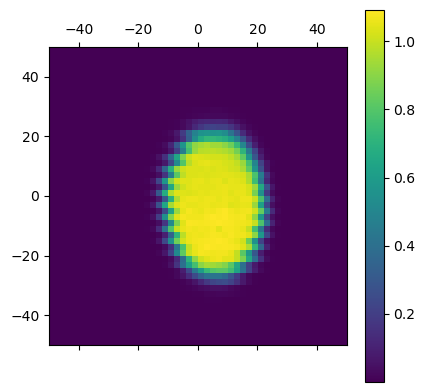

In [4]:
N_pts = 50
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 50
# cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_pm10_rand10_lin70,jac_master_mask=A_POS_ALL_MASK,jac_x0 = jac_pm10_rand10_lin70_x0)
cf = lambda para: callback_func(para,pos_mask=POS_MASK)
X1,Y1,Z1 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
# np.savez("/home/rydpiservo/servodata/servosetup1/scan_AXXDOT_pm10+rand10+lin70.npz",X1=X1,Y1=Y1,Z1=Z1)

2024-10-24 18:30:24,064 - INFO - z0: ((0, 0), 0.4291875)
100%|██████████| 900/900 [04:37<00:00,  3.24it/s]
2024-10-24 18:35:01,450 - INFO - going home


0.5025000000000001
0.0005625000000000001


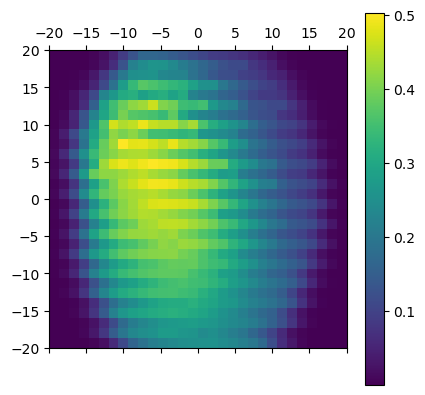

In [31]:
N_pts = 30
POS_MASK = A_X_Y_MASK
SCAN_RANGE = 20
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_pm10_rand10,jac_master_mask=A_POS_ALL_MASK,jac_x0 = jac_pm10_rand10_x0)
X2,Y2,Z2 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
np.savez("/home/rydpiservo/servodata/servosetup2/scan_AXY_pm10+rand10.npz",X2=X2,Y2=Y2,Z2=Z2)

2024-10-09 18:54:34,491 - INFO - z0: ((0, 0), 0.4435)
100%|██████████| 2500/2500 [14:58<00:00,  2.78it/s]
2024-10-09 19:09:33,215 - INFO - going home


0.49293750000000003
0.0005


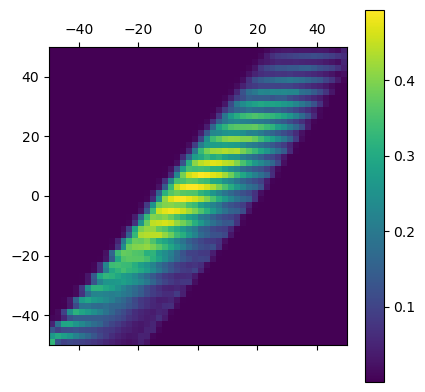

In [44]:
N_pts = 50
POS_MASK = A_X_XDOT_MASK
SCAN_RANGE = 50
cf = lambda para: callback_func(para,pos_mask=POS_MASK,jac=jac_pm_10+lin70,jac_master_mask=A_POS_ALL_MASK,jac_x0 = jac_pm_10)
X2,Y2,Z2 = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)

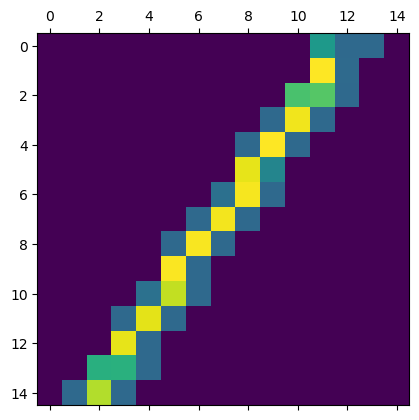

In [24]:
Z_acc = accept_func_AYYDOT([X,Y])
plt.matshow(Z_acc*(0.3)+Z)

In [26]:
idxmax = np.argmax(Z)
idxi,idxj = np.unravel_index(idxmax,X.shape)
maxpos = [X[idxi,idxj],Y[idxi,idxj]]
print(cf(maxpos))

((-2.8571428571428577, -20.0), 2.0479375)


In [27]:
servos.set_zero()

2024-10-09 16:27:52,737 - INFO - Setting Zero
2024-10-09 16:27:52,773 - INFO - [TxRxResult] There is no status packet!
2024-10-09 16:27:52,783 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,789 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,796 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,802 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,808 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,814 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,820 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,828 - ERROR - Servo 1x: Read not sucessful!
2024-10-09 16:27:52,864 - INFO - Servo 1x: result [TxRxResult] There is no status packet!
2024-10-09 16:27:52,864 - INFO - Servo 1x: SCServo zero set!
2024-10-09 16:27:52,900 - INFO - [TxRxResult] There is no status packet!
2024-10-09 16:27:52,912 - ERROR - Servo 1y: Read not sucessful!
2024-10-09 16:27:52,918 - ERROR - Servo 1y: Read not sucessful!
2024-10-09 16:27:

2024-10-08 17:01:20,351 - INFO - z0: ((0, 0), 0.0011250000000000001)
100%|██████████| 50/50 [00:16<00:00,  2.98it/s]
2024-10-08 17:01:37,148 - INFO - going home
2024-10-08 17:01:39,347 - INFO - z0: ((0, 0), 1.0058125)
100%|██████████| 50/50 [00:15<00:00,  3.23it/s]
2024-10-08 17:01:54,821 - INFO - going home
2024-10-08 17:01:56,982 - INFO - z0: ((0, 0), 1.0484375)
100%|██████████| 50/50 [00:14<00:00,  3.36it/s]
2024-10-08 17:02:11,861 - INFO - going home
2024-10-08 17:02:13,547 - INFO - z0: ((0, 0), 1.0663125)
100%|██████████| 50/50 [00:15<00:00,  3.33it/s]
2024-10-08 17:02:28,579 - INFO - going home
2024-10-08 17:02:30,277 - INFO - z0: ((0, 0), 1.040125)
100%|██████████| 50/50 [00:15<00:00,  3.30it/s]
2024-10-08 17:02:45,450 - INFO - going home
2024-10-08 17:02:47,684 - INFO - z0: ((0, 0), 0.0022500000000000003)
100%|██████████| 50/50 [00:15<00:00,  3.14it/s]
2024-10-08 17:03:03,619 - INFO - going home
2024-10-08 17:03:05,849 - INFO - z0: ((0, 0), 0.0010625)
100%|██████████| 50/50 [00

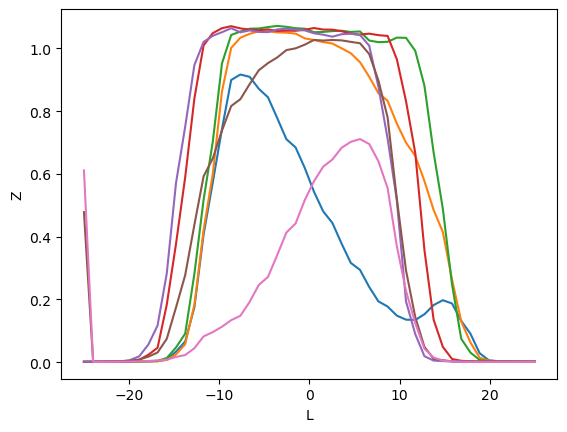

In [44]:
N_pts = 50
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 25
data=[]
for i in range(-3,4):
    zero = np.array([0,0,0,0,i*100,0,-67*i,0])
    cf = lambda para: callback_func(para,pos_mask=POS_MASK,zero=zero)
    vec = slope2perpvec(-0.67)
    L,Z = motor_1d_scan(N_pts,SCAN_RANGE,vec,servos,cf)
    data.append((i,L,Z))

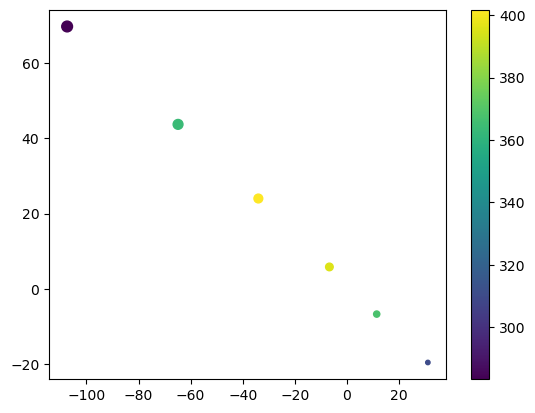

In [91]:
import pickle
with open("/home/rydpiservo/servodata/servorecover2/xxdot_scan_when_moving_yydot.pkl","rb") as f:
    dataYoffset = pickle.load(f)

muList = []
sigmaList = []
for i in range(-2,4):
    for j in range(len(dataYoffset)):
        if dataYoffset[j][0] == i:
            mu,cov  = dataYoffset[j][1]
            # print(mu)
            muList.append(mu)
            eigval,eigvec = np.linalg.eig(cov)
            sigma = np.sqrt(eigval)
            sigmaList.append(sigma[0])

xList=[mu[0] for mu in muList]
yList=[mu[1] for mu in muList]
plt.scatter(xList,yList,s=np.arange(len(xList))*10+10,c=sigmaList)
plt.colorbar()

In [94]:
i=1
zero = np.array([0,0,0,0,0,100*i,0,-67*i])
zero[4]=-33.99
zero[6]=23.99
print(zero)

[  0   0   0   0 -33 100  23 -67]


2024-10-08 17:57:40,633 - INFO - z0: ((0, 0), 0.0011875)
100%|██████████| 50/50 [00:16<00:00,  3.10it/s]
2024-10-08 17:57:56,777 - INFO - going home
2024-10-08 17:57:59,014 - INFO - z0: ((0, 0), 0.5298125)
100%|██████████| 50/50 [00:15<00:00,  3.33it/s]
2024-10-08 17:58:14,025 - INFO - going home
2024-10-08 17:58:16,253 - INFO - z0: ((0, 0), 0.8908125)
100%|██████████| 50/50 [00:14<00:00,  3.39it/s]
2024-10-08 17:58:31,022 - INFO - going home
2024-10-08 17:58:33,246 - INFO - z0: ((0, 0), 0.9359375)
100%|██████████| 50/50 [00:14<00:00,  3.41it/s]
2024-10-08 17:58:47,912 - INFO - going home
2024-10-08 17:58:50,140 - INFO - z0: ((0, 0), 0.0015)
100%|██████████| 50/50 [00:15<00:00,  3.33it/s]
2024-10-08 17:59:05,147 - INFO - going home
2024-10-08 17:59:07,374 - INFO - z0: ((0, 0), 0.0011250000000000001)
100%|██████████| 50/50 [00:16<00:00,  3.12it/s]
2024-10-08 17:59:23,397 - INFO - going home
2024-10-08 17:59:25,624 - INFO - z0: ((0, 0), 0.0009375)
100%|██████████| 50/50 [00:16<00:00,  3.

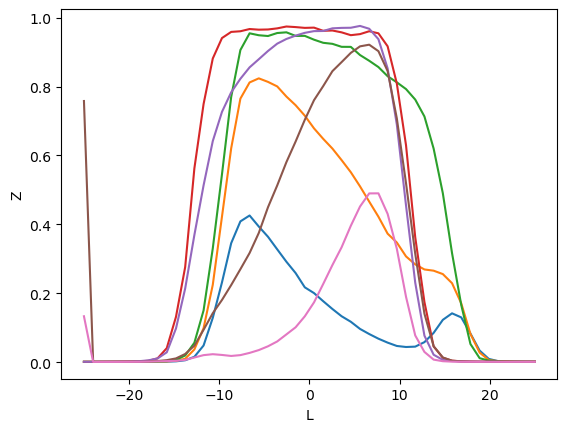

In [84]:
N_pts = 50
POS_MASK = B_X_XDOT_MASK
SCAN_RANGE = 25
dataXoffset=[]
idx=0
xxdot =muList[0]
yydot = np.array([100*(-2+idx),(-67)*(-2+idx)])
# for i in range(-3,4):
#     zero = np.array([0,0,0,0,xxdot[0]+ i*100, yydot[0],xxdot[1]+i*(-67),yydot[1]])
#     cf = lambda para: callback_func(para,pos_mask=POS_MASK,zero=zero)
#     vec = slope2perpvec(-0.67)
#     L,Z = motor_1d_scan(N_pts,SCAN_RANGE,vec,servos,cf)
#     dataXoffset.append((i,L,Z))

In [85]:
with open("/home/rydpiservo/servodata/servorecover2/xxdot_1dscan_at_yydot=mu[0].pkl","wb") as f:
    pickle.dump(dataXoffset,f)

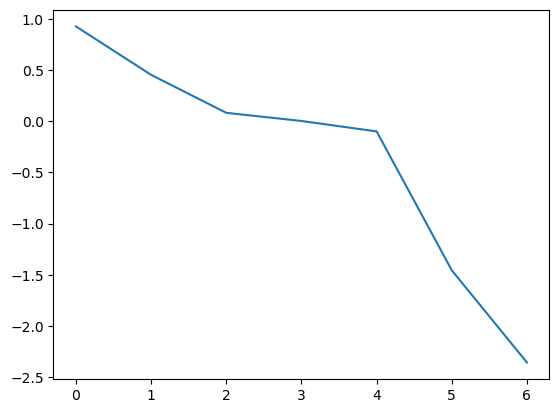

In [86]:
LList = [L for i,L,Z in dataXoffset]
ZList = [Z for i,L,Z in dataXoffset]
skewnesList = [statistics_skewness(L,Z) for L,Z in zip(LList,ZList)]
plt.plot(skewnesList)

2024-10-07 17:19:38,776 - INFO - z0: ((0, 0), 1.0434375)
100%|██████████| 1600/1600 [02:40<00:00,  9.98it/s]
2024-10-07 17:22:19,072 - INFO - going home


1.0469375
0.0


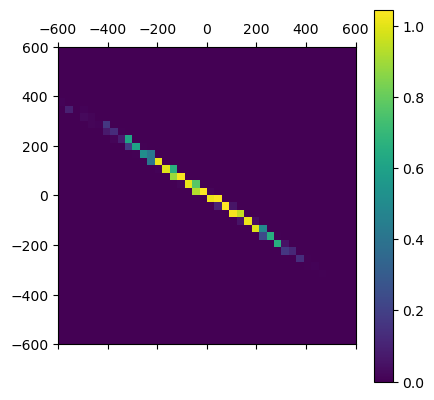

In [19]:
# N_pts = 100
N_pts = 40
POS_MASK = B_X_XDOT_MASK
# SCAN_RANGE = 500 if POS_MASK==B_X_XDOT_MASK else 800
SCAN_RANGE = 600 if POS_MASK==B_X_XDOT_MASK else 800
cf = lambda para: callback_func(para,pos_mask=POS_MASK)
scan_start_time = time.time()
# X,Y,Z = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf)
X,Y,Z = motor_2d_scan(N_pts,SCAN_RANGE,servos,cf,accept_func=posmask2acceptfunc(POS_MASK))
scan_stop_time = time.time()
posmaskstr = posmask2str(POS_MASK)
fileName="clip_{}_{}".format(posmaskstr,ITER_NUM)
# np.savez("/home/rydpiservo/servodata/servorecover/{}_re_large.npz".format(fileName),X=X,Y=Y,Z=Z,posmask = POS_MASK,posmaskstr = posmaskstr,ITER_NUM=ITER_NUM,scan_start_time=scan_start_time,scan_stop_time=scan_stop_time)

Initial guess for p0:  [-1.21959840e+00 -6.02702012e+00  3.97677009e+04 -2.65656531e+04
  1.78664619e+04  1.00000000e-01]


/home/rydpiservo/expctl/src/expctl/servers/servoaligner/fit_gaussian.py:21: RuntimeWarning: overflow encountered in exp
  smooth_transition = 1 / (1 + np.exp((quadratic_form - 1) / transition_width))


[-6.35724952e-01 -6.30042667e+00  1.40510622e+05 -9.40867544e+04
  6.33826458e+04  1.97106768e-01]
[451.25376272  16.22680028]


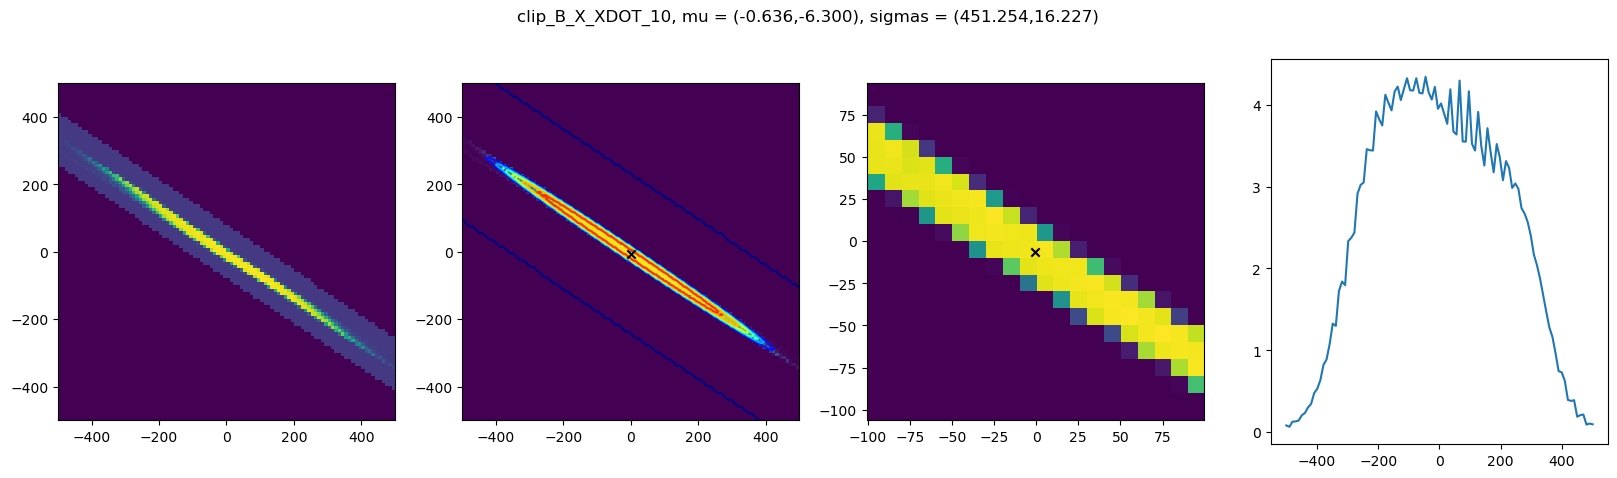

In [19]:
fig,ax = plt.subplots(1,4,figsize=(20,5))
Z_norm = Z/np.max(Z)

# ax0. accept_func
ax0 = ax[0]
Zacc = np.zeros_like(X)
if isinstance(N_pts,int):
    N_pts_x,N_pts_y = N_pts,N_pts
elif isinstance(N_pts,tuple):
    N_pts_x,N_pts_y = N_pts

accept_func = posmask2acceptfunc(POS_MASK)
xy = np.array([X, Y])  # Combine X and Y arrays
Zacc = accept_func(xy).astype(int)  # Apply the acceptance function and convert to int
ax0.imshow(Zacc*0.2+Z_norm, extent=[X.min(), X.max(), Y.min(), Y.max()],origin='lower')

# ax1. fit_gaussian_2d
ax1 = ax[1]
popt=fit_and_plot_smooth_heaviside(X,Y,Z,ax=ax1)
mu,cov = popt_get_mu_cov(popt)
ax1.scatter(mu[0],mu[1],marker='x',color='black',zorder=10)
eigvals, eigvecs = np.linalg.eig(cov)
sigmas= np.sqrt(eigvals)
print(popt)
print(sigmas)
np.savez("/home/rydpiservo/servodata/servorecover/{}_popt.npz".format(fileName),popt=popt,mu=mu,cov=cov,sigmas=sigmas)

# ax2. central point magnify
ax2 = ax[2]
ax2.imshow(Z_norm, extent=[X.min(), X.max(), Y.min(), Y.max()],origin='lower')
ax2.scatter(mu[0],mu[1],marker='x',color='black')
ax2.set_xlim([mu[0]-100,mu[0]+100])
ax2.set_ylim([mu[1]-100,mu[1]+100])

# ax3, row sum
ax3 = ax[3]
Z_row = np.sum(Z,axis=0)
ax3.plot(X[0,:],Z_row)
#
# suptitle
fig.suptitle("{}, mu = ({:.3f},{:.3f}), sigmas = ({:.3f},{:.3f})".format(fileName,mu[0],mu[1],sigmas[0],sigmas[1]))
plt.savefig("/home/rydpiservo/servodata/servorecover/{}.png".format(fileName),dpi=300,bbox_inches='tight')


In [21]:
cf(list(mu))
time.sleep(1)
logging.info("going to mu: {}".format(mu))
_,I = cf(list(mu))
logging.info("I: {}".format(I))
if I>0.3:
    logging.info("setting zero point")
    # servos.set_zero()
else:
    logging.info("I too small, not setting zero point")
time.sleep(1)


2024-10-05 20:46:54,185 - INFO - going to mu: [-0.63572495 -6.30042667]
2024-10-05 20:46:54,415 - INFO - I: 1.106875
2024-10-05 20:46:54,418 - INFO - setting zero point


## Iterative Spiral Optimization

In [4]:
zero = np.array([0,0,0,0,0,0,0,0],dtype=float)
offset = np.array([0,0,0,0],dtype=float)

2024-10-02 17:17:58,664 - INFO - Offset = [0. 0. 0. 0.], Zero = [ 0.          0.          0.          0.         10.18064443  1.12136333
 -7.22576165 -1.44739995]
2024-10-02 17:17:58,667 - INFO - Start optimization with zero = [ 0.          0.          0.          0.         10.18064443  1.12136333
 -7.22576165 -1.44739995]
2024-10-02 17:17:58,844 - INFO - Start position: x_0=0.00 x_1=0.00 x_2=0.00 x_3=0.00, start I: 0.404625


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -3.97188D-01    |proj g|=  6.58875D-02

At iterate    1    f= -4.00313D-01    |proj g|=  5.69875D-02

At iterate    2    f= -4.09938D-01    |proj g|=  6.02250D-02
  ys=-6.987E-05  -gs= 7.989E-04 BFGS update SKIPPED


2024-10-02 17:18:23,497 - INFO - Converged position: x_0=-0.03 x_1=-0.00 x_2=-0.07 x_3=-0.04
2024-10-02 17:18:23,498 - INFO - Best point: x_0=-0.06 x_1=5.00 x_2=-0.19 x_3=-0.16; T=0.42262500000000003



At iterate    3    f= -4.08250D-01    |proj g|=  6.06750D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4      3     14      3     1     0   6.067D-02  -4.083D-01
  F = -0.40825000000000000     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


2024-10-02 17:18:23,875 - INFO - Best position: x_0=-0.06 x_1=5.00 x_2=-0.19 x_3=-0.16, now I: 0.38175000000000003
2024-10-02 17:18:23,876 - INFO - New Origin set to be x_0=-0.06 x_1=5.00 x_2=-0.19 x_3=-0.16
2024-10-02 17:18:23,877 - INFO - Zero = [ 0.          0.          0.          0.         10.12463103  6.11854646
 -7.42008895 -1.60549327]


0.4003125


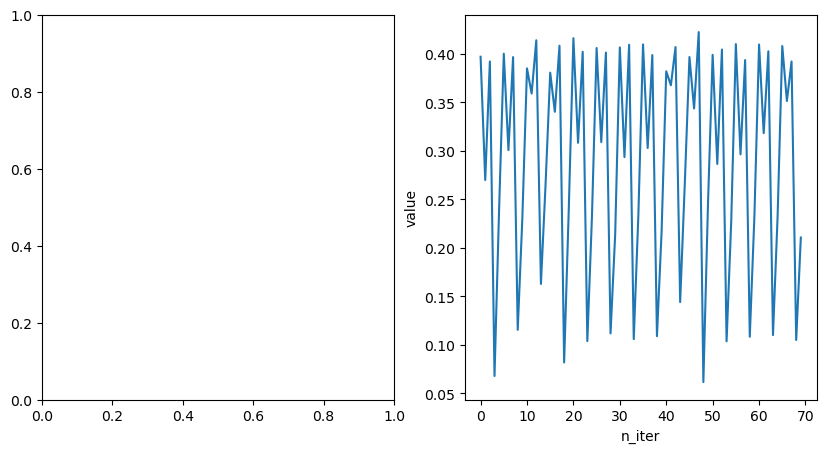

In [9]:
offset_mask = A_POS_ALL_MASK
logging.info(f"Offset = {offset}, Zero = {zero}")
#
#
try:
    logging.info(f"Start optimization with zero = {zero}")
    # zero = step_optimize(servos,callback_func,pos_mask = B_X_Y_MASK,zero=zero,bounds_single = (-100,100))
    # zero = step_optimize(servos,callback_func,pos_mask = B_X_XDOT_MASK,zero=zero)
    # zero = step_optimize(servos,callback_func,pos_mask = B_Y_YDOT_MASK,zero=zero)
    zero = step_optimize(servos,callback_func,pos_mask = B_POS_ALL_MASK,zero=zero,method='L-BFGS-B')
    #
    _,I = callback_func(zero,pos_mask=POS_ALL_MASK)
    print(I)
    #
    # dataset[tuple(offset)].append((list(zero),I))
    # print(dataset)
    # np.save(filename,dataset)
    # print("i=",i)

except Exception as e:
    servos.close()
    logging.error(f"Error in iterative_optimize: {e}")